In [5]:
# Import necessary libraries for data handling, computation, and visualization
import os
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sbn


directory = 'C:\\Users\\Hp\\OneDrive - University of Aberdeen\\BT5511 - computation assignment\\files'
#here each file will be read as datafile and it will be added into this list

dataframes = []

for filename in os.listdir(directory):#to loop through all file names
    if filename.endswith('.txt'): #to process file names that only end with .txt
        filepath = os.path.join(directory, filename) 
        df = pd.read_csv(filepath, sep='\t') #to read the file
        dataframes.append(df)  

combined_dataframe = pd.concat(dataframes, ignore_index=True)#to combine multiple data frames together


aggregated_data = {} #a dictionary to make a table of aggregated data

#new function defined to find the type of the mutation
def identify_mutation_type(wild_type, mutant):
    if wild_type == mutant:
        return 'No Mutation'
    elif len(wild_type) == len(mutant):
        if re.search(r'[ATGC]+', wild_type) and re.search(r'[ATGC]+', mutant):
            return 'Substitution'
    elif len(wild_type) < len(mutant):
        return 'Insertion'
    else:
        return 'Deletion'
        
#a new function defined to find the location of the mutation and to find out if the mutation is in promoter region or coding region
def mutation_location_and_region(wild_type,mutant):
    sequence_length = min(len(wild_type), len(mutant))
    for i in range(sequence_length):
        if wild_type[i] != mutant[i]: # Check if there is a mismatch at this position
            region = "Promoter" if i < 1000 else "Coding" # Classify the mutation as occurring in the 'Promoter' region if within the first 1000 bases; otherwise, it's in the 'Coding' region
            return "Mutation", i, region
    if len(wild_type) != len(mutant):
        return "Insertion/Deletion", sequence_length, "Promoter" if sequence_length < 1000 else "Coding" 
    
    # if no mutation found
    return "No Mutation", None, None

#to understand the effect of mutation on cell viability,mRNA expression and protien expression 
#percentage change is calculated by establishing a new function
def percent_change(wild_type, mutant):
    percentage_change = ((mutant - wild_type)/wild_type)*100
    return percentage_change

def fold_change(wild_type, mutant): #it finds out how many times the mutant value changes to the wild type
    fold_change = mutant/ wild_type
    return fold_change

def log2_fold_change(wild_type, mutant): 
    log2_fc = np.log2(mutant/wild_type)
    log2_fc = np.where(np.isnan(log2_fc) | np.isinf(log2_fc), np.nan, log2_fc)
    return log2_fc
    
    
for filename in os.listdir(directory):
    if filename.endswith('.txt'):   # to find out all .txt files 
        filepath = os.path.join(directory, filename)  
        try:
            df = pd.read_csv(filepath, sep='\t')   # to read all datframes using pandas\ and to seperate columns using tab 
            
            gene_name = df['Gene'].iloc[0]  
            wild_type_sequence = df['WildType.Sequence'].iloc[0]  
            mutant_sequence = df['Mutant.Sequence'].iloc[0]  
            
            mutation_type = identify_mutation_type(wild_type_sequence, mutant_sequence)
            mutation_location = mutation_location_and_region(wild_type_sequence, mutant_sequence)
            
            mRNA_WT = df[[col for col in df.columns if 'mRNA.Expression.WT' in col]].mean(axis=1).iloc[0]
            mRNA_Mut = df[[col for col in df.columns if 'mRNA.Expression.Mut' in col]].mean(axis=1).iloc[0]
            mRNA_expression_change = percent_change(mRNA_WT, mRNA_Mut)
            mRNA_fc = fold_change(mRNA_WT, mRNA_Mut)
            mRNA_log2fc = log2_fold_change(mRNA_WT, mRNA_Mut)
           
            
            protein_WT = df[[col for col in df.columns if 'Protein.Expression.WT' in col]].mean(axis=1).iloc[0]
            protein_Mut = df[[col for col in df.columns if 'Protein.Expression.Mut' in col]].mean(axis=1).iloc[0]
            protein_expression_change = percent_change(protein_WT, protein_Mut)
            protein_fc = fold_change(protein_WT, protein_Mut)
            protein_log2fc = log2_fold_change(protein_WT, protein_Mut)

            cell_viability_WT = df[[col for col in df.columns if 'CellViability.WT' in col]].mean(axis=1).iloc[0]
            cell_viability_Mut = df[[col for col in df.columns if 'CellViability.Mut' in col]].mean(axis=1).iloc[0]
            cell_viability_change= percent_change(cell_viability_WT, cell_viability_Mut)
            cell_viability_fc = fold_change(cell_viability_WT, cell_viability_Mut)
            cell_viability_log2fc = log2_fold_change(cell_viability_WT, cell_viability_Mut)

            
            aggregated_data[gene_name] = {
                'Gene': gene_name,
                'WildType.Sequence': wild_type_sequence,
                'Mutant.Sequence': mutant_sequence,
                'Mutation.Type': mutation_type,
 	  'Mutation.Location': mutation_location,
                'mRNA_WT': mRNA_WT,
                'mRNA_Mut': mRNA_Mut,
                'protein_WT': protein_WT,
                'protein_Mut': protein_Mut,
                'cell_viability_WT': cell_viability_WT,
                'cell_viability_Mut': cell_viability_Mut,
                'mRNA_expression_change': mRNA_expression_change,
                'protein_expression_change': protein_expression_change,
                'cell_viability_change': cell_viability_change,
                'mRNA.fc': mRNA_fc,
                'protein.fc': protein_fc,
                'cell_viability.fc': cell_viability_fc,
                'mRNA.log2fc': mRNA_log2fc,
                'protein.log2fc': protein_log2fc,
                'cell_viability.log2fc': cell_viability_log2fc
     
            }
            
        except Exception as e: #print an error message if anything goes wrong
            print(f"Error processing {filename}: {e}")



summary_table = pd.DataFrame.from_dict(aggregated_data, orient='index')


plot_df	=	pd.DataFrame(summary_table)	
plot_df

#assigning weightage to cell_viability to prioritize that metric in order to rank the top genes
cell_viability_weightage = 2
#A score is calculated for each gene by summing Log2 fold change of mRNA expression, protein expression and weighted log2 fold change of cell viability
summary_table['combined_score'] = summary_table['mRNA.log2fc'] + summary_table['protein.log2fc'] + cell_viability_weightage* summary_table['cell_viability.log2fc']
summary_table


C:\Users\Hp\AppData\Local\Temp\ipykernel_13132\728142859.py:63: RuntimeWarning: invalid value encountered in log2
  log2_fc = np.log2(mutant/wild_type)
C:\Users\Hp\AppData\Local\Temp\ipykernel_13132\728142859.py:63: RuntimeWarning: divide by zero encountered in log2
  log2_fc = np.log2(mutant/wild_type)
C:\Users\Hp\AppData\Local\Temp\ipykernel_13132\728142859.py:63: RuntimeWarning: divide by zero encountered in log2
  log2_fc = np.log2(mutant/wild_type)
C:\Users\Hp\AppData\Local\Temp\ipykernel_13132\728142859.py:63: RuntimeWarning: divide by zero encountered in log2
  log2_fc = np.log2(mutant/wild_type)


,Gene,WildType.Sequence,Mutant.Sequence,Mutation.Type,Mutation.Location,mRNA_WT,mRNA_Mut,protein_WT,protein_Mut,cell_viability_WT,...,mRNA_expression_change,protein_expression_change,cell_viability_change,mRNA.fc,protein.fc,cell_viability.fc,mRNA.log2fc,protein.log2fc,cell_viability.log2fc,combined_score
Ah3,Ah3,TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...,TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...,Substitution,"(Mutation, 734, Promoter)",1.061045e+08,1.061045e+08,25176.666667,25184.000000,0.540463,...,0.000001,0.029127,10.951202,1.000000e+00,1.000291e+00,1.109512,1.4727120279044253e-08,0.0004201597956590824,0.14992530200010298,0.300271
Alli2r,Alli2r,TTCTAACATGCGATCCTAGCGAGGGTTGTGTCGGACGTGAGCGGTG...,TTCTAACATGCGATCCTAGCGAGGGTTGTGTCGGACGTGAGCGGTG...,Insertion,"(Mutation, 997, Promoter)",4.005106e+02,4.004839e+02,21626.666667,21637.666667,0.253687,...,-0.006675,0.050863,-8.631195,9.999333e-01,1.000509e+00,0.913688,-9.629761561267191e-05,0.0007336133285338894,-0.130226407449671,-0.259815
Alli8,Alli8,TTTACCAGAATCTATAACAGTATATGGCAAAATTCTCCCGCGTACT...,TTTACCAGAATCTATAACAGTATATGGCAAAATTCTCCCGCGTACT...,Substitution,"(Mutation, 252, Promoter)",2.765717e+01,2.692833e+01,20556.333333,20565.333333,0.136534,...,-2.635272,0.043782,12.092492,9.736473e-01,1.000438e+00,1.120925,-0.03852887470060521,0.0006315043444407128,0.16468964769786332,0.291482
Anap7c1,Anap7c1,GGGCGCATAGTAGGCAAGACACCTATTGCTAAAAAACGTCCTGGAC...,GGGCGCATAGTAGGCAAGACACCTATTGCTAAAAAACGTCCTGGAC...,Substitution,"(Mutation, 494, Promoter)",9.957710e+00,-3.957048e+01,21147.666667,10071.333333,0.522474,...,-497.385305,-52.376149,-100.000000,-3.973853e+00,4.762385e-01,0.000000,nan,-1.0702437991084368,nan,NaN
App1l8,App1l8,ATCTTATCGTACACTATTAATAAACTAGCGCTGATTCGAGTCGCTC...,ATCTTATCGTACACTATTAATAAACTAGCGCTGATTCGAGTCGCTC...,Insertion,"(Mutation, 763, Promoter)",4.057949e+00,3.632353e+00,26965.333333,26974.000000,0.316194,...,-10.487965,0.032140,-30.149174,8.951204e-01,1.000321e+00,0.698508,-0.15984642039362354,0.0004636081447788536,-0.5176509196673516,-1.194685
App8,App8,CGGGAAGCTAACTTACTCATAAAGCCCGGTTCGAATAACATTTTGA...,CGGGAAGCTAACTTACTCATAAAGCCCGGTTCGAATAACATTTTGA...,Substitution,"(Mutation, 643, Promoter)",2.435471e+00,2.497834e+00,16175.666667,16183.000000,0.433318,...,2.560589,0.045336,-17.892991,1.025606e+00,1.000453e+00,0.821070,0.03647644885555352,0.0006539060415125703,-0.28442271336038355,-0.531715
Avon1a5,Avon1a5,ACTCCATGGCCATTTACCGGGGATTTCAACGCGATACTCCTTAGAT...,ACTCCATGGCCATTTACCGGGGATTTCAACGCGATACTCCTTAGAT...,Substitution,"(Mutation, 829, Promoter)",7.714530e+01,7.751793e+01,22752.333333,22765.666667,0.535115,...,0.483027,0.058602,9.353458,1.004830e+00,1.000586e+00,1.093535,0.006951823403151149,0.0008452012139680557,0.12899884398383052,0.265795
Avon4,Avon4,TGAATCTAAGATTAAGTGGATATCGCCTTGACTTCTTTATCCATCC...,TGAATCTAAGATTAAGTGGATATCGCCTTGACTTCTTTATCCATCC...,Insertion,"(Mutation, 385, Promoter)",2.512790e+00,3.958356e+00,35318.333333,55350.000000,0.642143,...,57.528325,56.717474,812.235001,1.575283e+00,1.567175e+00,9.122350,0.6556112617226251,0.648166052969138,3.189405525527096,7.682588
Ben3l6,Ben3l6,CAACTTTAAGGAAGATGGTCGGTGCTTGATTCGTAAATCTGGTGTA...,CAACTTTAAGGAAGATGGTCGGTGCTTGATTCGTAAATCTGGTGTA...,Insertion,"(Mutation, 601, Promoter)",8.745566e+02,8.746048e+02,11301.333333,11314.333333,0.244863,...,0.005521,0.115031,25.714045,1.000055e+00,1.001150e+00,1.257140,7.965199200864766e-05,0.0016585880817642023,0.3301458344421789,0.66203
Bma9,Bma9,CTACTTCCCCAAGCTCTTGAAATCTCGAAACATATTGTGCTGGTCC...,CTACTTCCCCAAGCTCTTGAAATCTCGAAACATATTGTGCTGGTCC...,Insertion,"(Mutation, 201, Promoter)",3.100805e+01,3.162820e+01,20849.333333,20864.000000,0.446393,...,1.999967,0.070346,-30.949395,1.020000e+00,1.000703e+00,0.690506,0.0285686911553442,0.0010145210870225233,-0.5342740401728547,-1.038965


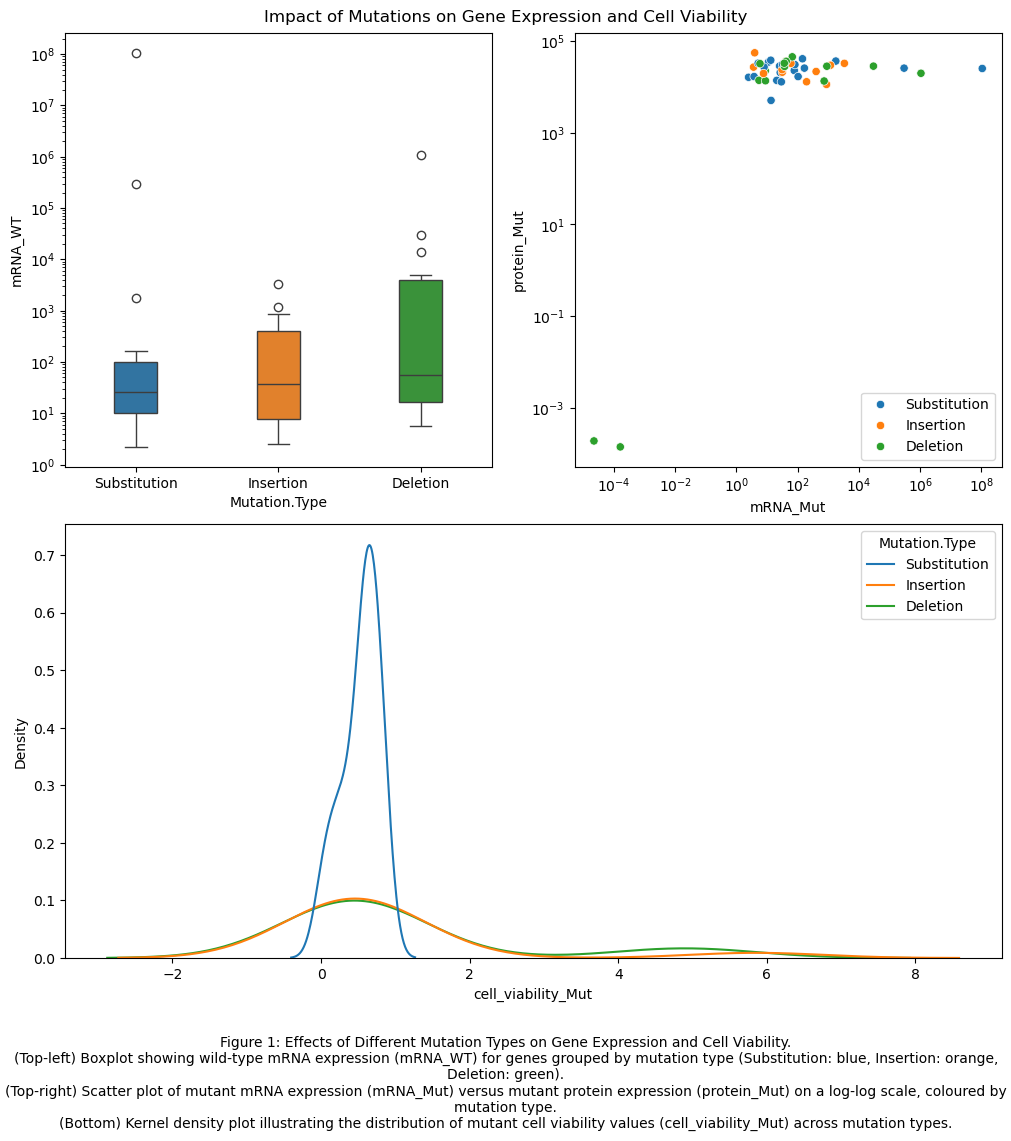

In [9]:
#To create a subplot layout
fig,ax = plt.subplot_mosaic([["box", "scatter"],["hist", "hist"]], figsize=(10,10), layout="constrained")

#To create a boxplot for mRNA_WT values for each mutation type
sbn.boxplot(plot_df, x="Mutation.Type", y="mRNA_WT", hue="Mutation.Type", width = 0.3,  ax=ax["box"])
ax["box"].set_yscale("log")#Log scale is used for better visual seperation of values
#A scatterplot is used to show the relationship between mRNA and protein levels in mutants
sbn.scatterplot(plot_df, x="mRNA_Mut", y="protein_Mut", hue="Mutation.Type", ax=ax["scatter"])
ax["scatter"].legend(loc = "lower right")
ax["scatter"].set_yscale("log")
ax["scatter"].set_xscale("log")
#KDE(Kernal Density Estimate) plot shows distribution of mutant cell viability for each mutation type
sbn.kdeplot(plot_df, x="cell_viability_Mut", hue="Mutation.Type", ax=ax["hist"])
fig.suptitle("Impact of Mutations on Gene Expression and Cell Viability")
fig.text(
    0.5, -0.03,
    "Figure 1: Effects of Different Mutation Types on Gene Expression and Cell Viability.\n"
    "(Top-left) Boxplot showing wild-type mRNA expression (mRNA_WT) for genes grouped by mutation type "
    "(Substitution: blue, Insertion: orange, Deletion: green).\n"
    "(Top-right) Scatter plot of mutant mRNA expression (mRNA_Mut) versus mutant protein expression (protein_Mut) "
    "on a log-log scale, coloured by mutation type.\n"
    "(Bottom) Kernel density plot illustrating the distribution of mutant cell viability values (cell_viability_Mut) across mutation types.",
    ha='center', va='top', wrap=True, fontsize=10
)
plt.savefig("C:\\Users\\Hp\\OneDrive\\Desktop\\multipanel_plot.png")
plt.show()


In [11]:
#To sort all genes in descending order of combined_score
top_genes = summary_table.sort_values(by='combined_score', ascending=False).head(5)
plot_df = pd.DataFrame(top_genes) #overwrites plot_df with a new dataframe containing only the top genes
plot_df

,Gene,WildType.Sequence,Mutant.Sequence,Mutation.Type,Mutation.Location,mRNA_WT,mRNA_Mut,protein_WT,protein_Mut,cell_viability_WT,...,mRNA_expression_change,protein_expression_change,cell_viability_change,mRNA.fc,protein.fc,cell_viability.fc,mRNA.log2fc,protein.log2fc,cell_viability.log2fc,combined_score
Avon4,Avon4,TGAATCTAAGATTAAGTGGATATCGCCTTGACTTCTTTATCCATCC...,TGAATCTAAGATTAAGTGGATATCGCCTTGACTTCTTTATCCATCC...,Insertion,"(Mutation, 385, Promoter)",2.512790e+00,3.958356e+00,35318.333333,55350.000000,0.642143,...,57.528325,56.717474,812.235001,1.575283,1.567175,9.122350,0.6556112617226251,0.648166052969138,3.189405525527096,7.682588
Nect1c1,Nect1c1,ATACCTCTTTGGCTCCAATCCTAGTAAGGACCGAGTCGTTTATCTT...,ATACCTCTTTGGCTCCAATCCTAGTAAGGACCGAGTCGTTTATCTT...,Deletion,"(Mutation, 489, Promoter)",9.645300e+00,8.901433e+00,30209.666667,13595.666667,0.300318,...,-7.712226,-54.995642,1477.398961,0.922878,0.450044,15.773990,-0.11578856093574459,-1.1518633694797966,3.979475692334141,6.691299
Ever6b6,Ever6b6,AAGTTATTCTACGGGCCCTCTATTGAATAGATAACCCAGGGGCGTG...,AAGTTATTCTACGGGCCCTCTATTGAATAGATAACCCAGGGGCGTG...,Deletion,"(Mutation, 452, Promoter)",1.059454e+06,1.059454e+06,19785.666667,19795.000000,0.232951,...,-0.000077,0.047172,56.930616,0.999999,1.000472,1.569306,-1.107957561173651e-06,0.0006803904581969427,0.6501268376623146,1.300933
Jok4a3,Jok4a3,TATGAATAATTTCGAAAGACCGTATCACTGTGTGACCTGTAGTCCC...,TATGAATAATTTCGAAAGACCGTATCACTGTGTGACCTGTAGTCCC...,Substitution,"(Mutation, 310, Promoter)",2.209348e+00,3.786969e+00,16793.000000,16800.000000,0.683846,...,71.406629,0.041684,0.983486,1.714066,1.000417,1.009835,0.7774229077428823,0.0006012482024463263,0.014119391696145032,0.806263
Daz2b7,Daz2b7,CGATAAACTGAGATTGGGGGGACCCCTCTCATCCCCCACTCCTAAA...,CGATAAACTGAGATTGGGGGGACCCCTCTCATCCCCCACTCCTAAA...,Substitution,"(Mutation, 247, Promoter)",8.060128e+01,8.134645e+01,30539.666667,30548.333333,0.580531,...,0.924505,0.028378,29.437697,1.009245,1.000284,1.294377,0.013276503884256793,0.0004093555888201788,0.3722578405721373,0.758202


In [19]:
#to save the top genes as an excel file
top_genes.to_excel("C:\\Users\\Hp\\OneDrive\\Desktop\\top_5_genes.xlsx")